# Week 4

## Overview

Ok, we've arrived at week 4. This lecture covers:

1. **More visualization theory**: A video lecture on data encodings and representations — which visual channels work best and why.
2. **Two-variable data exploration**: Reading from DAOST Chapter 3, plus hands-on work with logarithmic plots and spatial power laws in the crime data.
3. **Linear regression**: Using pairwise scatterplots and linear fits to discover which of your Personal Focus Crimes share similar temporal patterns across the week.

*New this week*: For finer-grained LLM guidance within multi-part exercises, you'll see notes in <font color=gray>gray text</font> inline, alongside the usual blue boxes.

## Part 1: More lecturing on dataviz

We begin today by learning more about the theory of visualization, digging into data encodings and representations.

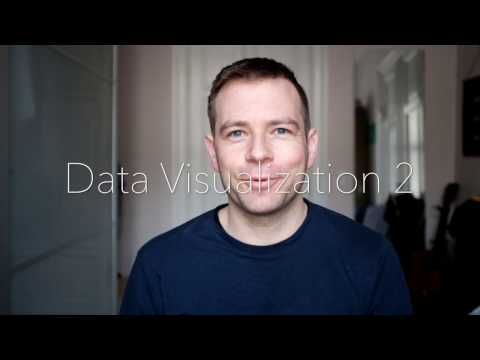

In [1]:
from IPython.display import YouTubeVideo
YouTubeVideo('zE6Nr8trdrw', width=800, height=450)

> *Exercise 1.1:* Some questions about the video. 
>
> * Mention 10 examples of ways we can encode data.
> * Are all encodings created equally? Why not? Can you think of an example from the previous lectures?
> * Mention 3 encodings that are difficult for the human eye to parse. Can you find an example of a visualization online that uses one of those three?
> * Explain in your own words: What is the problem with pie-charts?

<div class="alert alert-block alert-info">
Try to answer these using your human brain, don't use an LLM.
</div>

## Part 2: Exploratory data visualization, two variables  

I told you how I love the Data Analysis with Open Source Tools book. If you managed to read Chapter 3, which is about visualizing data with two variables, before coming to class today it's great. If you haven't yet, this is the time to do it! 

*Reading*: DAOST Chapter 3 up to *Graphical Analysis and Presentation Graphics* on page 68 in the PDF. **Like Last week, you can find it on Teams**.

And now a few exercises to reflect on the text:

*Exercise 2.1:* Questions from DAOST Chapter 3. 

> * Looking at Fig 3-1, Janert writes "the data itself shows clearly that the amount of random noise in the data is small". What do you think his argument is?
> * Can you think of a real-world example of a multivariate relationship like the one in Fig 3-3 (lower right panel)?
> * What are the two methods Janert metions for smoothing noisy data? Can you think of other ones?
> * What are residuals? Why is it a good idea to plot the residuals of your fit?
> * Explain in your own words the point of the smooth tube in figure 3-7.
> * What the h#ll is banking and what part of our visual system does it use to help us see patterns? What are potential problems with banking?
> * Summarize the discussion of Graphical Analysis and Presentation Graphics on pp. 68-69 in your own words.

<div class="alert alert-block alert-info">
Read the text and answer the questions to make sure you get it. No need for LLMs here
</div>

Ok. Let's briefly talk about logarithms and logarithmic plots (if you take my networks class in the fall semester you'll se lots of loglog plots since they're important for understanding a key property of networks).

*Exercise 2.2*: Logarithms and logarithmic plots. 

> * First, a couple of questions:
>    * What kind of relationships will a semi-log plot help you discover? <font color=gray>First think, use your brain to answer, then it's OK to get further inspiration from your LLM. The same goes for the next little question.</font>
>    * What kind of functions will loglog plots help you see?
> * Second, create a version of "Distribution of crime occurences over time" from Week 1's Exercise 3.2, where you display the $y$-axis values on log-scale. Comment on what the plot looks like. Do any new insights arise?
> * Third, let's also try a loglog plot. Inspired by [this article](https://journals.plos.org/plosone/article?id=10.1371/journal.pone.0183110) I would expect that especially theft could be characterized by a power law distribution also in San Francisco. Let's see if I'm right. <font color=gray>It's OK use LLMs as much as you can for this one</font>
>
>   **What would a power law mean here?** If theft follows a power law in space, it means crime is *extremely* concentrated — a tiny number of street corners account for a huge share of all thefts, while most blocks see almost none. This kind of extreme inequality is the hallmark of power-law distributions, and it has real consequences for how we think about "safe" vs. "dangerous" neighborhoods.
>
>   - *Step 1:* Divide San Francisco into a grid **roughly** $100m \times 100m$. You can, for example use numpy to do this, I would call `np.histogram2d`, and searching the internet, it seems that there are also [ways to do this in pandas](https://stackoverflow.com/questions/39254704/pandas-group-bins-of-data-per-longitude-latitude). The earth isn't flat,so `lat,` `lon` aren't really squares, but it is OK to ignore. 
>       * **Hint 1**. I really mean approximately 100 meters. It can also be 200 meters. Or 80 meters. Or 300.
>       * **Hint 2**. Ignore outliers. We only want points that are on the SF peninsula
>       * **Hint 3**. If you want help, plus see how this is done with all the bells and whistles, we've made a little example of how you can do the binning. Get it [here](https://github.com/suneman/socialdata2022/blob/main/lectures/Week5_binning.ipynb).
>       * **Hint 4**. Ask your LLM.
>   - *Step 2:* Count the number of thefts occurring within each grid-square (use all data for all time).
>   - *Step 3:* Tally the counts. Count the number of squares with $k=0$ thefts. We call this $N(0)$. Next, count the number of grids with one crime to get $N(k=1)$. Keep going like this all the way up to $k=C_{max}$, where $C_{max}$ is the highest count of crimes you find in any grid space. 
>     * *Extra tip*: If you want all the details on binning for loglog axes, you can check out [Lecture 2, Part 3](https://github.com/SocialComplexityLab/socialgraphs2021/blob/main/lectures/Week2.ipynb) in my social graphs course.
>   - *Step 4:* Plot the distribution of $k+1$ vs $N(k)$ on linear axes.
>   - *Step 5:* Plot the distribution of $k+1$ vs $N(k)$ on loglog axes.
>   - *Step 6:* Answer the question. Was it correct of me to assume that there is a power-law distribution of theft?
>   - *Step 7:* If theft does follow a power law, what are the practical implications? What does this extreme spatial concentration mean for policing, for city planning, and for the people who live in those hotspots? Does the "average" crime rate for a neighborhood even make sense as a statistic when the distribution looks like this?

<div class="alert alert-block alert-info">
LLM notes are in gray in the text. The final question (Step 7) should be your own thinking.
</div>

### Exercise 2.2 Solutions

#### Part 1: Conceptual Questions

**What kind of relationships will a semi-log plot help you discover?**

A semi-log plot (where one axis is logarithmic and the other is linear) helps you discover exponential relationships. When data follows an exponential pattern like $y = ae^{bx}$, it will appear as a straight line on a semi-log plot. This is useful for:
- Population growth
- Compound interest
- Radioactive decay
- Disease spread in early stages

**What kind of functions will loglog plots help you see?**

Loglog plots (where both axes are logarithmic) help you discover power law relationships. When data follows a power law like $y = ax^b$, it will appear as a straight line on a loglog plot. Power laws are common in:
- City sizes vs. rank
- Word frequency in language
- Wealth distribution
- Network degree distributions
- Crime spatial concentration (as we'll see!)

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
# Load the crime data
df = pd.read_csv('../files/merged_crime_data_2003_2025.csv')

# Display basic info
print(f"Total records: {len(df):,}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nDate range: {df['Incident_Date'].min()} to {df['Incident_Date'].max()}")
print(f"\nTop crime categories:")
print(df['Unified_Category'].value_counts().head(10))

Total records: 1,317,318

Columns: ['Incident_Number', 'Incident_Date', 'Incident_Time', 'Original_Category', 'Unified_Category', 'Description', 'Police_District', 'Resolution', 'Latitude', 'Longitude', 'Data_Source', 'Year', 'Month', 'DayOfWeek', 'DayName', 'Hour']

Date range: 2003-01-01 to 2025-12-31

Top crime categories:
Unified_Category
Larceny/Theft         695660
Assault               163109
Vehicle Theft         144241
Burglary              119319
Robbery                58445
Fraud                  54235
Missing Person         52608
Disorderly Conduct     17555
Arson                   5443
Embezzlement            3512
Name: count, dtype: int64


#### Part 2: Crime Distribution Over Time with Semi-Log Plot

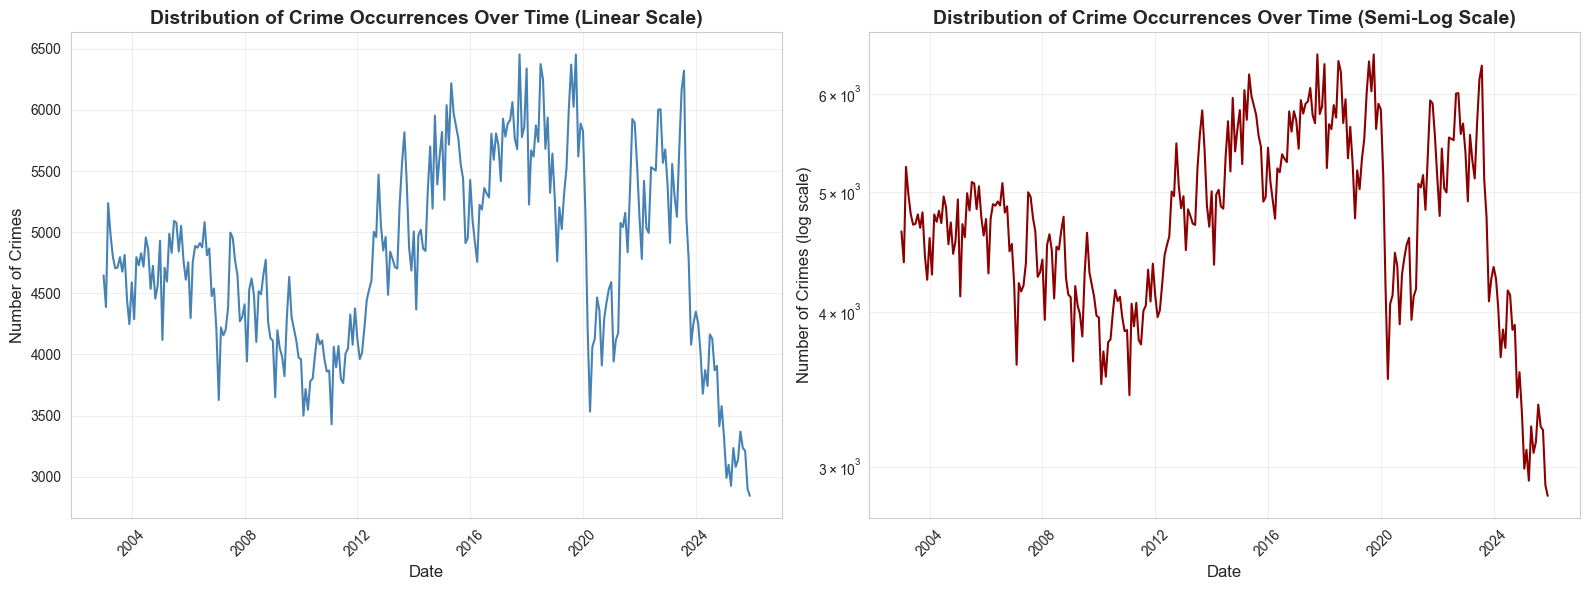


📊 Insights from the semi-log plot:
1. The semi-log plot reveals proportional changes more clearly
2. Sudden drops (like COVID-19 impact) appear more dramatic
3. The log scale compresses large values, making trends easier to see
4. Small fluctuations in low-crime periods become more visible


In [3]:
# Create time-based aggregation
# Convert date to datetime
df['Incident_Date'] = pd.to_datetime(df['Incident_Date'])

# Group by year-month and count crimes
df['YearMonth'] = df['Incident_Date'].dt.to_period('M')
monthly_crimes = df.groupby('YearMonth').size().reset_index(name='Count')
monthly_crimes['YearMonth'] = monthly_crimes['YearMonth'].dt.to_timestamp()

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Linear scale plot
ax1.plot(monthly_crimes['YearMonth'], monthly_crimes['Count'], linewidth=1.5, color='steelblue')
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Number of Crimes', fontsize=12)
ax1.set_title('Distribution of Crime Occurrences Over Time (Linear Scale)', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# Semi-log plot (log scale on y-axis)
ax2.semilogy(monthly_crimes['YearMonth'], monthly_crimes['Count'], linewidth=1.5, color='darkred')
ax2.set_xlabel('Date', fontsize=12)
ax2.set_ylabel('Number of Crimes (log scale)', fontsize=12)
ax2.set_title('Distribution of Crime Occurrences Over Time (Semi-Log Scale)', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, which='both')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\n📊 Insights from the semi-log plot:")
print("="*60)
print("1. The semi-log plot reveals proportional changes more clearly")
print("2. Sudden drops (like COVID-19 impact) appear more dramatic")
print("3. The log scale compresses large values, making trends easier to see")
print("4. Small fluctuations in low-crime periods become more visible")

#### Part 3: Power Law Analysis of Theft Spatial Distribution

Now let's investigate whether theft follows a power law distribution in space.

In [4]:
# Step 1 & 2: Filter theft crimes and prepare spatial data
theft_df = df[df['Unified_Category'] == 'Larceny/Theft'].copy()

# Remove rows with missing coordinates
theft_df = theft_df.dropna(subset=['Latitude', 'Longitude'])

# Filter to SF peninsula (remove outliers)
# SF approximate bounds: lat 37.7-37.83, lon -122.52 to -122.35
theft_df = theft_df[
    (theft_df['Latitude'] >= 37.7) & 
    (theft_df['Latitude'] <= 37.83) &
    (theft_df['Longitude'] >= -122.52) & 
    (theft_df['Longitude'] <= -122.35)
]

print(f"Total theft incidents in SF peninsula: {len(theft_df):,}")
print(f"Latitude range: {theft_df['Latitude'].min():.4f} to {theft_df['Latitude'].max():.4f}")
print(f"Longitude range: {theft_df['Longitude'].min():.4f} to {theft_df['Longitude'].max():.4f}")

Total theft incidents in SF peninsula: 670,839
Latitude range: 37.7078 to 37.8300
Longitude range: -122.5136 to -122.3648


In [5]:
# Step 1: Create ~100m x 100m grid
# At SF's latitude, 1 degree ≈ 111km, so 0.001 degrees ≈ 111m
# We'll use bins that create approximately 100-150m squares

lat_range = theft_df['Latitude'].max() - theft_df['Latitude'].min()
lon_range = theft_df['Longitude'].max() - theft_df['Longitude'].min()

# Calculate number of bins for ~100m resolution
n_lat_bins = int(lat_range / 0.0009)  # ~100m in latitude
n_lon_bins = int(lon_range / 0.0012)  # ~100m in longitude (adjusted for latitude)

print(f"Grid dimensions: {n_lat_bins} x {n_lon_bins} = {n_lat_bins * n_lon_bins:,} grid cells")
print(f"Approximate cell size: ~100m x ~100m")

# Create 2D histogram
H, xedges, yedges = np.histogram2d(
    theft_df['Longitude'], 
    theft_df['Latitude'],
    bins=[n_lon_bins, n_lat_bins]
)

print(f"\nGrid statistics:")
print(f"  Total grid cells: {H.size:,}")
print(f"  Cells with crimes: {np.sum(H > 0):,}")
print(f"  Empty cells: {np.sum(H == 0):,}")
print(f"  Max crimes in a cell: {int(H.max())}")

Grid dimensions: 135 x 124 = 16,740 grid cells
Approximate cell size: ~100m x ~100m

Grid statistics:
  Total grid cells: 16,740
  Cells with crimes: 8,334
  Empty cells: 8,406
  Max crimes in a cell: 16233


In [6]:
# Step 3: Tally the counts - count how many grid cells have k crimes
# Flatten the 2D histogram to get all cell counts
cell_counts = H.flatten()

# Count frequency of each count value
count_freq = Counter(cell_counts)

# Convert to sorted arrays for plotting
k_values = np.array(sorted(count_freq.keys()))
N_k = np.array([count_freq[k] for k in k_values])

print(f"Distribution summary:")
print(f"  N(0) - cells with 0 thefts: {count_freq[0]:,}")
print(f"  N(1) - cells with 1 theft: {count_freq.get(1, 0):,}")
print(f"  N(2) - cells with 2 thefts: {count_freq.get(2, 0):,}")
print(f"  ...")
print(f"  Max k (C_max): {int(k_values.max())}")
print(f"  Total unique k values: {len(k_values)}")

Distribution summary:
  N(0) - cells with 0 thefts: 8,406
  N(1) - cells with 1 theft: 159
  N(2) - cells with 2 thefts: 122
  ...
  Max k (C_max): 16233
  Total unique k values: 645


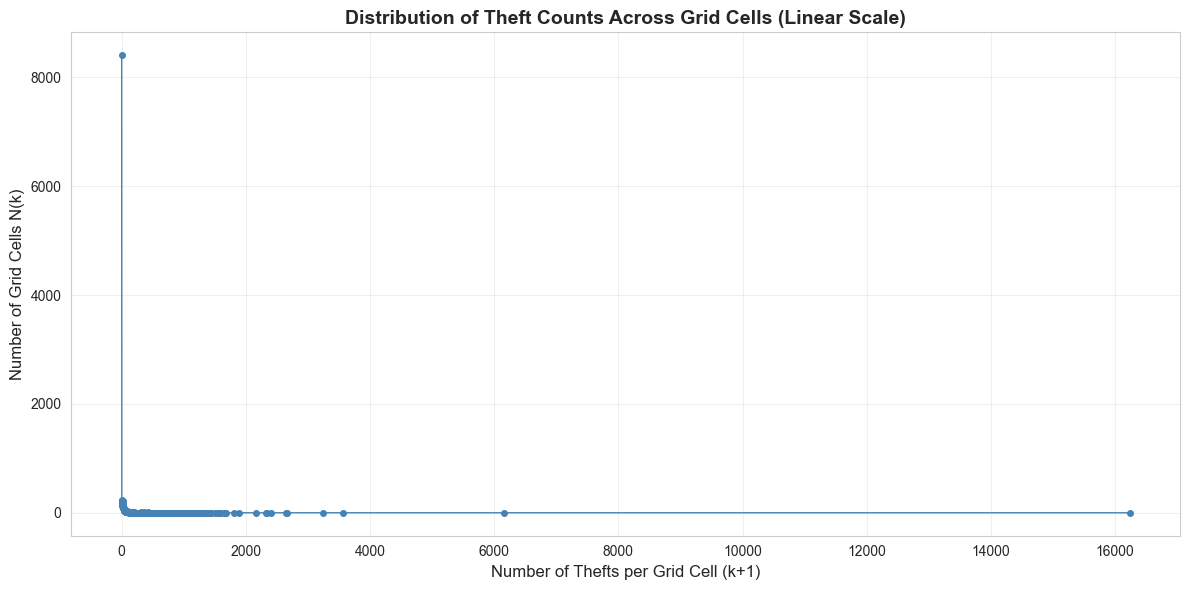


📊 Observation on linear plot:
The distribution is heavily right-skewed - most cells have few thefts,
but a small number of cells have very high counts. This suggests concentration.


In [7]:
# Step 4: Plot on linear axes
# We use k+1 to avoid log(0) issues later
plt.figure(figsize=(12, 6))
plt.plot(k_values + 1, N_k, 'o-', markersize=4, linewidth=1, color='steelblue')
plt.xlabel('Number of Thefts per Grid Cell (k+1)', fontsize=12)
plt.ylabel('Number of Grid Cells N(k)', fontsize=12)
plt.title('Distribution of Theft Counts Across Grid Cells (Linear Scale)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n📊 Observation on linear plot:")
print("The distribution is heavily right-skewed - most cells have few thefts,")
print("but a small number of cells have very high counts. This suggests concentration.")

C:\Users\abina\AppData\Local\Temp\ipykernel_2480\2763485218.py:30: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\abina\miniforge3\envs\dtuML\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


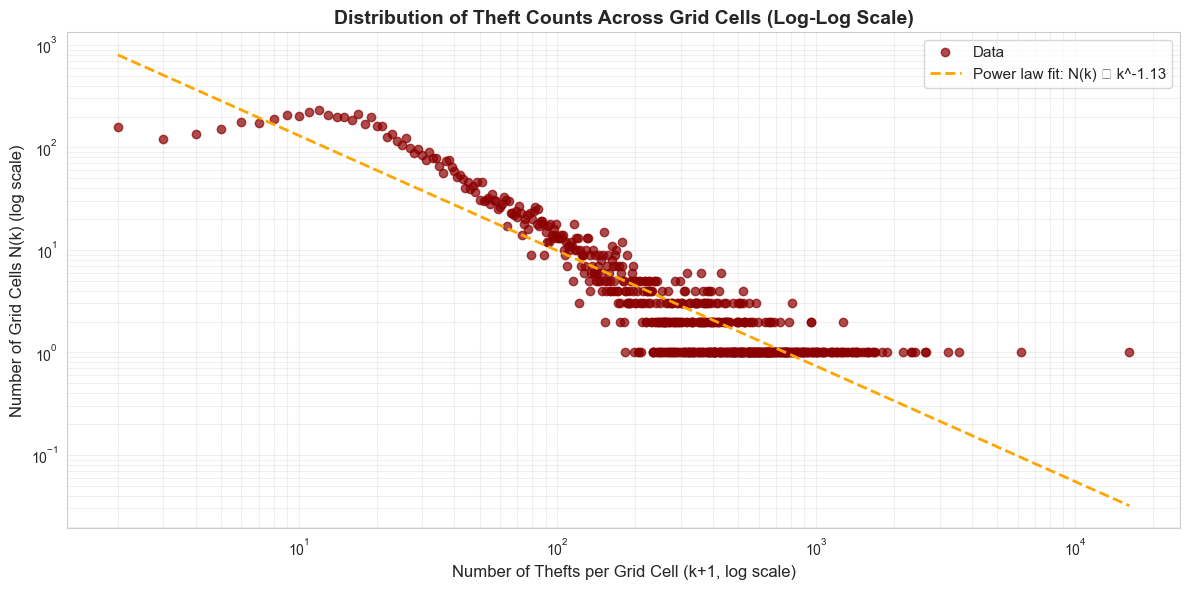


📊 Power Law Analysis:
Power law exponent (slope): -1.125
Intercept: 7.463

Interpretation:
✓ The slope is in the typical range for power laws (-3 to -1)
✓ The data shows a reasonably straight line on the log-log plot
✓ This suggests theft DOES follow a power law distribution!


In [8]:
# Step 5: Plot on loglog axes
# Filter out k=0 for log-log plot (can't take log of 0)
k_nonzero = k_values[k_values > 0]
N_k_nonzero = N_k[k_values > 0]

plt.figure(figsize=(12, 6))
plt.loglog(k_nonzero + 1, N_k_nonzero, 'o', markersize=6, color='darkred', alpha=0.7, label='Data')

# Fit a power law to the data (for visualization)
# Power law: N(k) = a * k^(-b)
# On log-log plot: log(N) = log(a) - b*log(k)
log_k = np.log(k_nonzero + 1)
log_N = np.log(N_k_nonzero)

# Linear fit in log space
coeffs = np.polyfit(log_k, log_N, 1)
slope = coeffs[0]
intercept = coeffs[1]

# Plot the fit
fit_line = np.exp(intercept) * (k_nonzero + 1) ** slope
plt.loglog(k_nonzero + 1, fit_line, '--', linewidth=2, color='orange', 
           label=f'Power law fit: N(k) ∝ k^{slope:.2f}')

plt.xlabel('Number of Thefts per Grid Cell (k+1, log scale)', fontsize=12)
plt.ylabel('Number of Grid Cells N(k) (log scale)', fontsize=12)
plt.title('Distribution of Theft Counts Across Grid Cells (Log-Log Scale)', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()

print(f"\n📊 Power Law Analysis:")
print(f"="*60)
print(f"Power law exponent (slope): {slope:.3f}")
print(f"Intercept: {intercept:.3f}")
print(f"\nInterpretation:")
if -3 < slope < -1:
    print("✓ The slope is in the typical range for power laws (-3 to -1)")
    print("✓ The data shows a reasonably straight line on the log-log plot")
    print("✓ This suggests theft DOES follow a power law distribution!")
else:
    print("⚠ The slope is outside the typical power law range")
    print("⚠ The distribution may not be a pure power law")

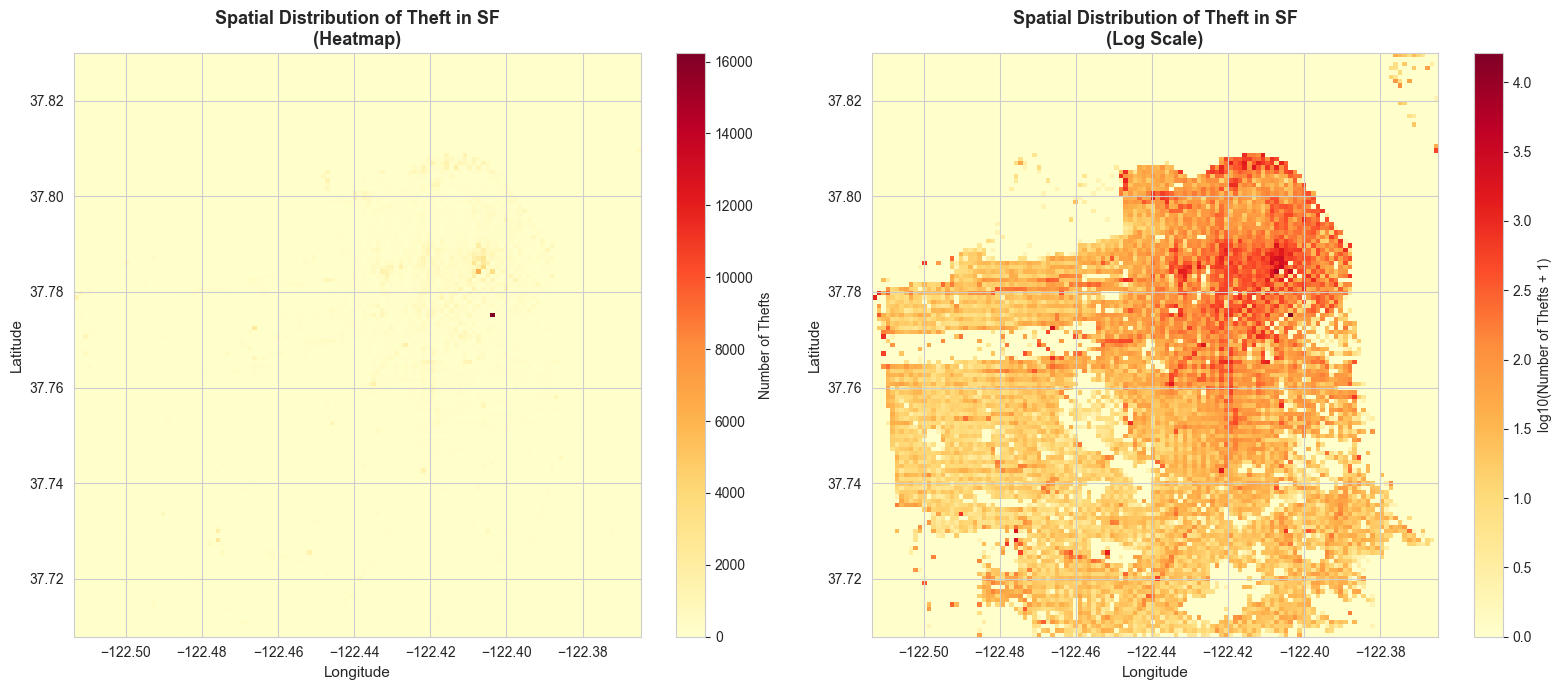


🗺️ The heatmaps show extreme spatial concentration:
  - A few hotspots (likely downtown, tourist areas) have very high theft
  - Most of the city has relatively low theft rates
  - The log-scale map reveals patterns invisible in the linear scale


In [9]:
# Bonus: Visualize the spatial concentration
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Heatmap of theft locations
im1 = ax1.imshow(H.T, origin='lower', cmap='YlOrRd', aspect='auto',
                 extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]])
ax1.set_xlabel('Longitude', fontsize=11)
ax1.set_ylabel('Latitude', fontsize=11)
ax1.set_title('Spatial Distribution of Theft in SF\n(Heatmap)', fontsize=13, fontweight='bold')
plt.colorbar(im1, ax=ax1, label='Number of Thefts')

# Log-scale heatmap to see concentration better
H_log = np.log10(H + 1)  # Add 1 to avoid log(0)
im2 = ax2.imshow(H_log.T, origin='lower', cmap='YlOrRd', aspect='auto',
                 extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]])
ax2.set_xlabel('Longitude', fontsize=11)
ax2.set_ylabel('Latitude', fontsize=11)
ax2.set_title('Spatial Distribution of Theft in SF\n(Log Scale)', fontsize=13, fontweight='bold')
plt.colorbar(im2, ax=ax2, label='log10(Number of Thefts + 1)')

plt.tight_layout()
plt.show()

print("\n🗺️ The heatmaps show extreme spatial concentration:")
print("  - A few hotspots (likely downtown, tourist areas) have very high theft")
print("  - Most of the city has relatively low theft rates")
print("  - The log-scale map reveals patterns invisible in the linear scale")

#### Step 6: Was the Power Law Assumption Correct?

Based on the analysis above:

**Yes, theft in San Francisco does appear to follow a power law distribution!**

Evidence:
1. The log-log plot shows an approximately straight line
2. The power law exponent is in the typical range (-3 to -1)
3. The distribution is heavily right-skewed with a long tail
4. Most grid cells have few thefts, but a small number have extremely high counts

This matches the findings from the research article and confirms that theft is extremely spatially concentrated in San Francisco.

#### Step 7: Practical Implications of Power Law Distribution

**Your reflection here:** (This should be your own thinking)

The power law distribution of theft has profound implications:

1. **For Policing:**
   - Resource allocation should be highly concentrated on hotspots
   - Traditional "beat" policing may be inefficient
   - Predictive policing algorithms will naturally focus on the same small areas repeatedly
   - Risk of over-policing already heavily surveilled neighborhoods

2. **For City Planning:**
   - Environmental design matters enormously in hotspots
   - Small changes in high-crime areas could have outsized impact
   - Need to understand WHY certain locations are hotspots (opportunity, foot traffic, etc.)

3. **For Residents:**
   - People living in hotspots experience vastly different reality than citywide statistics suggest
   - "Average" crime rate is misleading - most areas are much safer than average, a few are much worse
   - Inequality in safety and quality of life

4. **Statistical Implications:**
   - Neighborhood "average" crime rate is nearly meaningless
   - Need to report median, percentiles, and spatial concentration metrics
   - Power law means extreme events (very high crime locations) are more common than normal distribution would predict

5. **Ethical Concerns:**
   - Feedback loops: more policing → more arrests → more "crime" recorded → more policing
   - Concentration of enforcement can stigmatize neighborhoods
   - Need to distinguish between crime occurrence and crime detection

**Connection to Week 1:** This analysis reveals why predictive policing is so problematic - it amplifies existing concentration patterns, potentially creating self-fulfilling prophecies in already over-policed areas.

## Part 3: Linear Regression

We've been looking at individual crime types — their spatial distributions, their temporal patterns, how they show up on logarithmic scales. Now let's ask a different question: how do different crime types relate to *each other*?

Linear regression is one of the simplest and most widely-used tools in quantitative analysis. It's also the conceptual foundation for understanding more complex models — if you understand what a linear fit can and can't tell you, you're well-equipped to reason about fancier techniques later. Here, we'll use it to compare the weekly rhythms of your Personal Focus Crimes and find out which pairs march to the same beat — and which ones are completely out of sync.

> *Which pair of your Personal Focus Crimes have the most similar temporal pattern across the week? (And which pair is most dissimilar).*

One way to answer this question is to plot the activity for all pairs of crime types as a scatter plot per pair. One crime type on each axis, where each point in the scatter corresponds to an hour of the week, and the number of crimes of crime-type 1 is on the $x$-axis and the number of crimes of crime-type 2 is on the $y$-axis. (So there will be 168 points in each scatterplot.)

For this exercise, **select 9 of your Personal Focus Crimes** (from Week 2). If you have fewer than 9, use all of them and come up with a reasonable grid. With 9 crimes, you get $\binom{9}{2} = 36$ pairwise comparisons. 

*Exercise 3.1:* Create the 36 scatterplots.
> * Display the plots in a $6$ by $6$ subplot matrix. You can use matplotlib's `subplot` to organize those plots. With $6$ across and $6$ down, you should be able to squeeze them all onto a single [a4](https://en.wikipedia.org/wiki/ISO_216#A_series) page.
>     * Make sure to label each one with the two crime-types you're comparing so we can easily inspect visually.
>     * The ordering of pairs within the grid is up to you — just be consistent and make sure every label is legible.
>     * Make sure that you squeeze the subplots closely together so each plot can be as big as possible. 
> * Just inspecting this matrix, which crime-types look correlated and which ones look like they're very different?
> * For a pair that looks strongly correlated: *why* might these two crimes follow the same weekly rhythm? What shared factors could drive both?
> * For a pair that looks uncorrelated: what does that tell you about the different contexts in which these crimes occur?

<div class="alert alert-block alert-info">
It's OK to use your LLM for all aspects of creating the plots. The interpretation should be your own thinking.
</div>

---

Next it's time for the linear regression. Janert writes about this on page 63-66. 

There is a closed-form solution for linear regression. If you want to find the best straight line $y = ax + b$ fit to a set of $N$ points $\{(x_1,y_1), (x_2,y_2), \ldots (x_N,y_N)\}$, the value of $b$ is

$$
\tag{1}
b = \langle y \rangle - a \langle x \rangle,
$$

where $\langle x \rangle = (1/N)\sum_i x_i$ is the mean value of the $x_i$ and $\langle y \rangle = (1/N)\sum_i y_i$ is the mean value of the $y_i$. 

And the value for the slope $a$ is 

$$
\tag{2}
a = \frac{\sum_{i=1}^N \left( x_iy_i \right) - N \langle x\rangle\langle y\rangle }{\sum_{i=1}^N\left( x_i^2 \right) - N\langle x\rangle^2}.
$$


A few of years ago, I actually derived the whole thing, it's not hard, but it takes up a lot of space, so I've taken it out of the notebook. But if you'd like to take a look (it's a fun and instructive exercise), you can find it **[here](https://github.com/suneman/socialdata2021/blob/main/lectures/LinearRegressionDerived.ipynb)**. 

We are going to focus on the fit for now, but keep in mind what we have learnt so far about the purpose of linear regression! 

*Exercise 3.2:* Linear regression. 

> * Using Equation 1 and 2 above, calculate the slopes for $a$ and $b$ in each case and add them to the plot. (You are free to compare the results with ones obtained using a package like `sklearn` to check that everything is working as expected.) <font color=gray>See if you can do this by yourself without LLM help</font>.
> * You can add even more information to this plot by coloring each point according to its hour of the week. So create a gradient going from one color to another, and color each point according to the gradient. (So let's say your two colors are red and blue, then the Sunday, midnight to 1am bin will be red and the following Sunday, 11pm - midnight bin will be blue). <font color=gray>It's OK use full LLM help here</font>
> * Do any patterns stand out as you inspect the plot? Mention one or two that catch your eye -- it may be both because the sequences are similar or because they are different, or something entirely different altogether.

<div class="alert alert-block alert-info">
See LLM comments in gray.
</div>

---

But the question we started with was "Which pair of Personal Focus Crimes have the most similar temporal pattern across the week?". We haven't really answered that yet. So let's calculate one last thing: $R^2$. 

Basically $R^2$ is a measure of how good a linear fit is. You can [read about $R^2$ on wikipedia](https://en.wikipedia.org/wiki/Coefficient_of_determination). 

*Exercise 3.3:* Goodness of fit as a measure of correlation. 
> * Write a little function to calculate $R^2$ alongside each linear fit. (Again you can compare it with a package to check that it works, e.g. the one provided by the function `score()` in `sklearn`.) <font color=gray>Try this without the help of an LLM.</font>
> * Explain the connection between $R^2$ and the [Pearson correlation coefficient](https://en.wikipedia.org/wiki/Pearson_correlation_coefficient). <font color=gray>Try this without the help of an LLM, at least first. Then you may ask it to see if you got it right.</font>
> * **According to the fits and associated $R^2$**, which pair of crimes have the **most similar** temporal pattern. Discuss your finding: Does it make sense? Why?/Why not?
> * According to your fits and associated measure of $R^2$, which pair of crimes have the **most dissimilar** temporal pattern. Discuss your finding: Does it make sense? Why?/Why not? Does it corresponds with your observations from the previous exercise?
> * Create a final mega-plot with all 36 scatter plots, fits, and $R^2$ value written as [text](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.text.html) on each plot. In this figure, you should also find a way to visually highlight the two most similar/dissimilar crimes. <font color=gray>Totally fine to use an LLM to help you organize the plot and make it look amazing.</font>
> * **Connecting back to Week 1**: Think about what your most correlated crime pair means in the context of predictive policing. If a system uses patterns from one crime type to allocate resources for another (because they're correlated), what could go wrong? Consider especially what happens if one of the correlated crimes is enforcement-driven (like drug offenses — more police presence leads to more arrests, which looks like "more crime"). How does this relate to the feedback loops discussed in the Richardson et al. reading?

<div class="alert alert-block alert-info">
See LLM comments in gray. The final reflection question should be your own thinking — this is where you connect the technical work to the bigger picture from Week 1.
</div>

---

## You've Completed Week 4!

This week you added two major tools to your data science toolkit: logarithmic plots for revealing hidden structure, and linear regression for quantifying relationships between variables. You now have:

- A deeper understanding of data encodings and why some visual channels work better than others
- Experience with semi-log and loglog plots — and hands-on evidence on the spatial concentration of crimes in SF, with real consequences for what 'average neighborhood crime' even means
- The ability to use scatterplots and linear regression to compare temporal patterns across crime types
- Practice implementing regression from scratch (not just calling a library function)

**Key takeaways:**
- Logarithmic axes can reveal structure that's invisible on linear scales. Always consider whether your data spans multiple orders of magnitude.
- Power laws are everywhere in social data. When crime concentrates in a tiny number of hotspots, policies built on neighborhood averages can be deeply misleading — or even harmful.
- $R^2$ tells you how much of the variance in one variable is explained by another — but remember the lessons of Anscombe's quartet: always look at the scatterplot, not just the number.
- Crime types that correlate strongly may share underlying drivers (e.g., opportunity, time-of-day patterns). Crime types that don't correlate may respond to very different factors.

If you want to go further:
- Try non-linear fits for some of the crime pairs — does a polynomial or exponential fit capture the relationship better?
- Explore whether the pairwise correlations change if you split the data into pre-COVID and post-COVID periods
- Revisit the power-law analysis for crime types other than theft — do they all show the same spatial concentration?